In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II = (
    pl.read_parquet("../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_II/triad/iedb_II_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)

iedb_I = (
    pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_I/triad/iedb_I_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)

assay_type = (
    pl.read_parquet("../../data/iedb_meta/assay_type.parquet")
    .select(
        [
            "references",
            "receptor_id",
            "peptide",
            "mhc_1_name",
            "mhc_2_name",
            "assay_type",
        ]
    )
    .unique()
)


# iedb_I_at = iedb_I.explode("receptor_id").join(assay_type, on="receptor_id")
# iedb_II_at = iedb_II.explode("receptor_id").join(assay_type, on="receptor_id")
# # iedb_II = iedb_II.filter(pl.col("cognate")).explode("references")

# iedb_I = iedb_I.filter(pl.col("cognate")).explode("references")

# REMOVEME TO ADD BACK IN
iedb_II_annot = pl.read_parquet(
    "../../data/iedb_II_full/triad/iedb_II_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))

iedb_II = iedb_II.join(iedb_II_annot, on="job_name", how="anti")

# REMOVEME TO ADD BACK IN
iedb_I_annot = pl.read_parquet(
    "../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))

iedb_I = iedb_I.join(iedb_I_annot, on="job_name", how="anti")

# # additionally filter out
iedb_I = iedb_I.filter(pl.col("job_name") != "121f50b609621ebe92777820dad90eb9")


iedb_I_at = (
    iedb_I.explode("references", "receptor_id")
    .explode("references")
    .explode("receptor_id")
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
    )
)

iedb_II_at = (
    iedb_II.explode("references", "receptor_id")
    .explode("references")
    .explode("receptor_id")
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
    )
)

affinity = pl.read_parquet("../../data/iedb_meta/triad_affinity.parquet")

both_iedb = pl.concat(
    [iedb_I_at, iedb_II_at.select(pl.exclude("peptide_mean_pLDDT_II"))], how="align"
)

all_noncog = pl.concat(
    [iedb_I.filter(~pl.col("cognate")), iedb_II.filter(~pl.col("cognate"))], how="align"
)

In [7]:
set(iedb_I_at.columns) ^ set(iedb_II_at.columns)

{'peptide_mean_pLDDT_II',
 'tcr_1_j_gene',
 'tcr_1_v_gene',
 'tcr_2_j_gene',
 'tcr_2_v_gene'}

## Validating all units are nM


In [26]:
affinity.filter(pl.col("response").str.contains("KD")).select("units").unique()

units
str
"""nM"""


## Checking composition of SPR vs binding assay


In [43]:
all_affin = both_iedb.join(
    affinity,
    on=[
        "references",
        "receptor_id",
        "peptide",
        "mhc_1_name",
        "mhc_2_name",
        "assay_type",
    ],
)

In [ ]:
all_affin.filter(pl.col("response").str.contains("KD")).filter(
    pl.col("assay_type") != "surface plasmon resonance (SPR)"
).select("references").unique()

references
str
"""1030841"""
"""1032856"""


In [18]:
all_affin.filter(pl.col("assay_type") == "binding assay")

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references,assay_type,as_type_id,as_char_value,as_num_value,as_inequality,as_comments,mhc_class_right,category,response,units,obi_id
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,i64,str,f64,str,str,str,str,str,str,str
"""4b76870ca809ff64f6ffff3cd04971…",true,"""GTIRPEIPDYF""","""I""","""heavy""","""human""","""B*57:03""","""GSHSMRYFYTAMSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""GEDVEQSLFLSVREGDSSVINCTYTDSSST…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""DSSSTY""","""IFSNMDM""","""NKKDKH""","""CAVSGGYQKVTF""","""LNHDA""","""SQIVND""","""EKKES""","""CASTGSYGYTF""",false,"[0.86, 0.89, … 0.8]","[[0.03, 0.95, … 0.81], [0.95, 0.89, … 0.83], … [0.81, 0.83, … 0.88]]","[[0.76, 0.96, … 1.36], [0.94, 0.76, … 1.24], … [1.41, 1.41, … 0.76]]","[0.03, 0.89, … 0.88]",0.07,0.0,0.89,0.89,0.92,2.389707,…,5,23,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",94.626667,92.399112,91.640701,90.319434,92.320575,93.23641,89.158044,91.500238,96.3305,92.399198,94.161859,4.056131,4.591971,1.674838,2.218701,0.047706,0.047706,1.16,1.24,1.15,1.33,"""199396""","""1037171""","""binding assay""",194,"""Positive""",null,null,"""The epitope was selected from …","""I""","""T Cell""","""T cell- APC binding""",null,"""http://purl.obolibrary.org/obo…"
"""fb5176e1345b779276674a2e1cbb63…",true,"""ALWGPDPAAAF""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""GEDVEQSLFLSVREGDSSVINCTYTDSSST…","""beta""","""human""","""GAVVSQHPSWVICKSGTSVKIECRSLDFQA…","""DSSSTY""","""IFSNMDM""","""NKKDKH""","""CAVTKDTGFQKLVF""","""DFQATT""","""SNEGSKA""","""ASLTL""","""CSARDHFGGSGYEQFF""",false,"[0.67, 0.82, … 0.68]","[[0.02, 0.85, … 0.56], [0.85, 0.88, … 0.74], … [0.56, 0.74, … 0.85]]","[[0.76, 1.19, … 3.82], [1.09, 0.76, … 3.03], … [3.5, 3.32, … 0.76]]","[0.02, 0.88, … 0.85]",0.07,0.0,0.85,0.86,0.89,7.828436,…,0,20,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",78.21025,86.482222,88.918947,90.146038,85.075833,83.748724,83.322553,90.73206,76.756063,84.191641,90.982573,11.675566,5.764427,3.005379,7.828355,0.051861,0.051861,3.21,2.47,2.82,2.67,"""204653""","""1039796""","""binding assay""",576,"""Positive""",null,null,"""K562 cells expressing HLA-A*02…","""I""","""T Cell""","""qualitative binding""",null,"""http://purl.obolibrary.org/obo…"
"""561f3f1c17ae1c8afb371a231b28e8…",true,"""KSLTPEVRGYW""","""I""","""heavy""","""human""","""B*57:03""","""GSHSMRYFYTAMSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""GEDVEQSLFLSVREGDSSVINCTYTDSSST…","""beta""","""human""","""D

In [53]:
all_affin.filter(
    pl.col("assay_type") == "binding assay",
    ~pl.col("references").is_in(["1030841", "1032856"]),
).group_by("response", "references").agg(pl.len()).sort(by="references")

response,references,len
str,str,u32
"""T cell- APC binding""","""1025226""",18
"""qualitative binding""","""1032888""",10
"""off rate""","""1033026""",1
"""on rate""","""1033026""",1
"""off rate""","""1034243""",1
"""on rate""","""1034243""",1
"""T cell- APC binding""","""1037171""",21
"""qualitative binding""","""1039796""",35
"""T cell- APC binding""","""1041763""",1


In [28]:
all_affin.filter(pl.col("assay_type") == "surface plasmon resonance (SPR)")

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references,assay_type,as_type_id,as_char_value,as_num_value,as_inequality,as_comments,mhc_class_right,category,response,units,obi_id
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,i64,str,f64,str,str,str,str,str,str,str
"""83f4f66647dc7c0fc05c873496a405…",true,"""GTSGSPIIDK""","""I""","""heavy""","""human""","""A*11:01""","""GSHSMRYFYTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""AQSVTQLDSHVSVSEGTPVLLRCNYSSSYS…","""beta""","""human""","""EAGVAQSPRYKIIEKRQSVAFWCNPISGHA…","""SSYSPS""","""YTSAATLV""","""KKSETS""","""CWSPFGNEKLTF""","""SGHAT""","""FQNNGV""","""LKGVD""","""CASSLGQGSYEQYF""",false,"[0.84, 0.88, … 0.82]","[[0.03, 0.95, … 0.84], [0.95, 0.89, … 0.87], … [0.84, 0.87, … 0.88]]","[[0.76, 1.14, … 1.35], [0.97, 0.76, … 1.31], … [1.33, 1.4, … 0.76]]","[0.03, 0.89, … 0.88]",0.07,0.0,0.88,0.89,0.92,3.010958,…,18,25,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]",94.522353,83.219767,85.824561,92.153696,83.5962,95.953125,93.99617,86.185,95.051775,89.381752,93.767855,4.958915,4.696743,1.729901,2.730593,0.065198,0.065198,1.35,1.31,1.33,1.4,"""8773""","""1032274""","""surface plasmon resonance (SPR…",301,"""Positive-Low""",400000.0,""">""","""The equilibrium binding affini…","""I""","""T Cell""","""dissociation constant KD""","""nM""","""http://purl.obolibrary.org/obo…"
"""0e57837023c91a9ef06223a0993afe…",true,"""GTSGSPIVNR""","""I""","""heavy""","""human""","""A*11:01""","""GSHSMRYFYTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""GNSVTQMEGPVTLSEEAFLTINCTYTATGY…","""beta""","""human""","""EAGVAQSPRYKIIEKRQSVAFWCNPISGHA…","""ATGYPS""","""ATKADDK""","""RKETTS""","""CALDSGNTGKLIF""","""SGHAT""","""FQNNGV""","""LKGVD""","""CASTTGGGGYEQYF""",false,"[0.86, 0.91, … 0.85]","[[0.03, 0.95, … 0.87], [0.95, 0.89, … 0.91], … [0.87, 0.91, … 0.89]]","[[0.76, 1.04, … 1.21], [0.93, 0.76, … 1.01], … [1.2, 0.99, … 0.76]]","[0.03, 0.89, … 0.89]",0.07,0.0,0.9,0.91,0.94,2.483577,…,35,30,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 2.0], … [0.0, 0.0, … 0.0]]",95.024928,90.077805,91.28451,90.700612,91.281631,96.52375,96.602766,89.550833,95.033,92.739197,93.127578,4.418137,4.490039,1.59825,2.45031,0.064464,0.064464,1.21,1.01,1.2,0.99,"""8772""","""1032274""","""surface plasmon resonance (SPR…",301,"""Positive""",7350.0,null,"""The equilibrium binding affini…","""I""","""T Cell""","""dissociation constant KD""","""nM""","""http://purl.obolibrary.org/obo…"
"""0aef8333e64fbc047045626bafb8a9…",true,"""NQKLIANAF""","""I""","""heavy""","""human""","""B*15:01""","""GSHSMRYFYTAMSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""KQEVTQIPAALSVPEG

In [ ]:
from tcrtrifold.utils import generate_job_name
from tcrtrifold.cleaning import infer_hla_chain
from tcrtrifold.mhc import (
    B2M_HUMAN_SEQ,
    HLACodeWebConverter,
)
from tcrtrifold.utils import (
    generate_job_name,
    FORMAT_COLS,
    FORMAT_TCR_COLS,
    FORMAT_ANTIGEN_COLS,
    TCRDIST_COLS,
)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    xlabel: str,
    ylabel: str,
    method: str = "spearman",
    title: str | None = None,
):
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()

    ax.scatter(x, y, alpha=0.8, s=15)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.text(
        0.50,
        0.1,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )
    ax.set_yscale("log")

    if title:
        ax.set_title(title, fontsize=16)

    plt.tight_layout()
    return fig


import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D


def plot_correlation_cls(
    x, y, mhc_class, xlabel, ylabel, method="spearman", title=None
):
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    else:
        r, p = stats.spearmanr(x, y)

    fig, ax = plt.subplots()
    colors = ["tab:blue" if c == "I" else "tab:orange" for c in mhc_class]
    ax.scatter(x, y, c=colors, alpha=0.8, s=15)
    handles = [
        Line2D([], [], marker="o", linestyle="", color="tab:blue", label="MHC I"),
        Line2D([], [], marker="o", linestyle="", color="tab:orange", label="MHC II"),
    ]
    ax.legend(handles=handles, loc="best")

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.text(
        0.50,
        0.1,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )
    ax.set_yscale("log")
    if title:
        ax.set_title(title, fontsize=16)
    plt.tight_layout()
    return fig


def plot_af3_pti_pae_box(noncog_pae, cog_kd, cog_pae):
    noncog_pae = 31 - np.asarray(noncog_pae)  # 31 - PTI-PAE
    cog_kd = np.asarray(cog_kd)
    cog_pae = 31 - np.asarray(cog_pae)  # 31 - PTI-PAE

    logk = np.log10(1 / cog_kd)
    lo = int(np.floor(logk.min()))
    hi = int(np.ceil(logk.max()))

    data = [noncog_pae]
    labels_main = ["non-cognate"]
    labels_counts = [f"n = {len(noncog_pae)}"]

    for e in range(lo, hi):
        m = (logk >= e) & (logk < e + 1)
        if m.any():
            data.append(cog_pae[m])
            labels_main.append(rf"$10^{{{e}-{e+1}}}$")
            labels_counts.append(f"{np.sum(m)}")

    ns = [len(d) for d in data]

    pos = np.arange(len(data))
    fig, ax = plt.subplots()
    ax.boxplot(data, positions=pos, widths=0.6)
    ax.set_xticks(pos)
    ax.set_xticklabels(labels_counts)
    ax.set_ylabel("31 - PTI-PAE")

    ax2 = ax.secondary_xaxis("bottom")
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(pos)
    ax2.set_xticklabels(labels_main, rotation=90)
    ax2.tick_params(axis="x", pad=25)
    ax2.set_xlabel("Kd (1/M)")

    return fig, ax


from matplotlib.ticker import LogLocator, NullFormatter


def plot_af3_pti_pae_box_scatter(noncog_pae, cog_kd, cog_pae):
    noncog_pae = 31 - np.asarray(noncog_pae)  # 31 - PTI-PAE
    cog_kd = np.asarray(cog_kd)
    cog_pae = 31 - np.asarray(cog_pae)  # 31 - PTI-PAE

    logkd = np.log10(cog_kd)
    lo = int(np.floor(logkd.min()))
    hi = int(np.ceil(logkd.max()))

    data_cog = []
    labels_main = []
    labels_counts = []

    for e in range(lo, hi):
        m = (logkd >= e) & (logkd < e + 1)
        if m.any():
            data_cog.append(cog_pae[m])
            labels_main.append(rf"$10^{{{e}}}$-$10^{{{e+1}}}$")
            labels_counts.append(str(np.sum(m)))

    fig, (ax_non, ax_cog) = plt.subplots(
        1,
        2,
        sharex=False,
        sharey=True,
        figsize=(6, 6),
        gridspec_kw={"width_ratios": [1, 5]},
    )

    ax_non.boxplot([noncog_pae], positions=[0], widths=0.40)
    ax_non.set_xticklabels(["Noncognate"], fontsize=14)
    ax_non.tick_params(axis="x", rotation=90)
    ax_non.set_ylabel("31 - PTI-PAE", fontsize=16)
    ax_non.spines["right"].set_visible(False)

    ax_cog.invert_xaxis()
    ax_cog.scatter(cog_kd, cog_pae, s=10)
    ax_cog.set_xscale("log")
    ax_cog.tick_params(axis="x", labelsize=12)
    ax_cog.set_xlim(10**hi, 10**lo)
    ax_cog.spines["left"].set_visible(False)
    ax_cog.set_yticks([])

    ax_cog.set_xlabel("Kd (M)", fontsize=16)

    ax_box = ax_cog.twiny()
    ax_box.set_xlim(-0.5, len(data_cog) - 0.5)
    bp = ax_box.boxplot(
        data_cog,
        positions=np.arange(len(data_cog)),
        widths=0.6,
        # patch_artist=True,
    )
    ax_box.invert_xaxis()
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    ax_box.spines["left"].set_visible(False)

    # edge_colors = ["blue"] * 3 + ["green"] * 4

    # for box, c in zip(bp["boxes"], edge_colors):
    #     box.set_edgecolor(c)
    #     # box.set_linewidth(2)

    r, p = stats.spearmanr(cog_pae, cog_kd)
    ax_cog.text(
        0.02,
        0.95,
        f"All Kd Spearman r = {r:.2f}, p = {p:.2g}",
        transform=ax_cog.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=12,
    )

    msk = cog_kd > 10**-6
    r, p = stats.spearmanr(cog_pae[msk], cog_kd[msk])
    ax_cog.text(
        0.02,
        0.85,
        f"Phys. range Kd Spearman r = {r:.2f}, p = {p:.2g}",
        transform=ax_cog.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=12,
    )
    # ax_box.set_xticks(np.arange(len(data_cog)))
    # ax_box.set_xticklabels(labels_counts)

    # ax_box2 = ax_box.secondary_xaxis("bottom")
    # ax_box2.set_xlim(ax_box.get_xlim())
    # ax_box2.set_xticks(np.arange(len(data_cog)))
    # ax_box2.set_xticklabels(labels_main, rotation=90)
    # ax_box2.tick_params(axis="x", pad=25)
    # ax_box2.set_xlabel("Kd (M)")

    ax_box.patch.set_alpha(0)
    for sp in ax_box.spines.values():
        sp.set_visible(False)

    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)

    return fig, ax_non, ax_cog


def plot_af3_pti_pae_box_scatter(noncog_pae, cog_kd, cog_pae):
    noncog_pae = 31 - np.asarray(noncog_pae)  # 31 - PTI-PAE
    cog_kd = np.asarray(cog_kd)
    cog_pae = 31 - np.asarray(cog_pae)  # 31 - PTI-PAE

    logkd = np.log10(cog_kd)
    lo = int(np.floor(logkd.min()))
    hi = int(np.ceil(logkd.max()))

    data_cog = []
    labels_main = []
    labels_counts = []

    for e in range(lo, hi):
        m = (logkd >= e) & (logkd < e + 1)
        if m.any():
            data_cog.append(cog_pae[m])
            labels_main.append(rf"$10^{{{e}}}$-$10^{{{e+1}}}$")
            labels_counts.append(str(np.sum(m)))

    fig, (ax_non, ax_cog) = plt.subplots(
        1,
        2,
        sharex=False,
        sharey=True,
        figsize=(6, 6),
        gridspec_kw={"width_ratios": [1, 5]},
    )

    bp_non = ax_non.boxplot([noncog_pae], positions=[0], widths=0.7, patch_artist=True)
    for b in bp_non["boxes"]:
        b.set_edgecolor("red")
        b.set_facecolor("none")
    ax_non.set_xticklabels(["Noncognate"], fontsize=14)
    ax_non.tick_params(axis="x", rotation=90)
    ax_non.set_ylabel("31 - PTI-PAE", fontsize=16)
    ax_non.spines["right"].set_visible(False)

    ax_cog.invert_xaxis()
    ax_cog.scatter(cog_kd, cog_pae, s=10)
    ax_cog.set_xscale("log")
    ax_cog.tick_params(axis="x", labelsize=12)
    ax_cog.set_xlim(10**hi, 10**lo)
    ax_cog.spines["left"].set_visible(False)
    ax_cog.set_yticks([])

    ax_cog.set_xlabel("Kd (M)", fontsize=16)

    ax_box = ax_cog.twiny()
    ax_box.set_xlim(-0.5, len(data_cog) - 0.5)
    bp = ax_box.boxplot(
        data_cog,
        positions=np.arange(len(data_cog)),
        widths=1,
        patch_artist=True,
    )
    ax_box.invert_xaxis()
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    ax_box.spines["left"].set_visible(False)

    edge_colors = ["blue"] * 3 + ["green"] * 4
    for box, c in zip(bp["boxes"], edge_colors):
        box.set_edgecolor(c)
        box.set_facecolor("none")

    r, p = stats.spearmanr(cog_pae, cog_kd)
    ax_cog.text(
        0.02,
        0.95,
        f"All Kd Spearman r = {r:.2f}, p = {p:.2g}",
        transform=ax_cog.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=12,
    )

    msk = cog_kd > 10**-6
    r, p = stats.spearmanr(cog_pae[msk], cog_kd[msk])
    ax_cog.text(
        0.02,
        0.85,
        f"Phys. range Kd Spearman r = {r:.2f}, p = {p:.2g}",
        transform=ax_cog.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=12,
    )
    # ax_box.set_xticks(np.arange(len(data_cog)))
    # ax_box.set_xticklabels(labels_counts)

    # ax_box2 = ax_box.secondary_xaxis("bottom")
    # ax_box2.set_xlim(ax_box.get_xlim())
    # ax_box2.set_xticks(np.arange(len(data_cog)))
    # ax_box2.set_xticklabels(labels_main, rotation=90)
    # ax_box2.tick_params(axis="x", pad=25)
    # ax_box2.set_xlabel("Kd (M)")

    ax_box.patch.set_alpha(0)
    for sp in ax_box.spines.values():
        sp.set_visible(False)

    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)

    return fig, ax_non, ax_cog

In [ ]:
all_affin.filter(pl.col("as_num_value") > 10**3).select("references")

# EXCL ALREADY ANALZYed

references
str
"""1025104"""
"""1042784"""
"""1041763"""
"""1032856"""
"""1032888"""
…
"""1040001"""
"""1031507"""
"""1014229"""


## Box plot


(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='AF3-PTI-PAE'>)

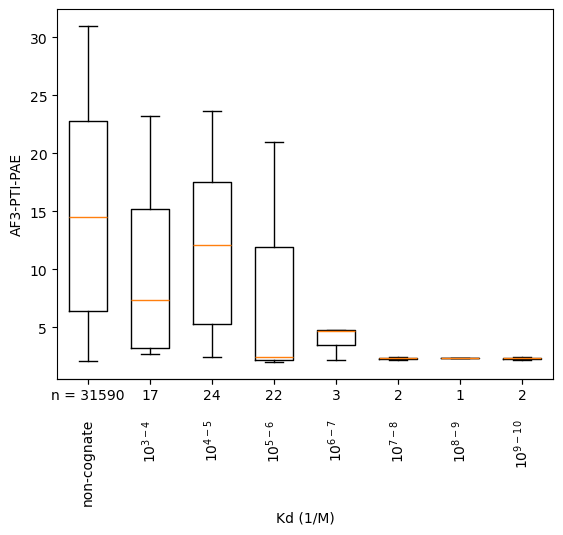

In [18]:
all_affin = (
    (
        both_iedb.join(
            affinity,
            on=[
                "references",
                "receptor_id",
                "peptide",
                "mhc_1_name",
                "mhc_2_name",
                "assay_type",
            ],
        )
    )
    .filter(pl.col("response").str.contains("KD"))
    .with_columns((pl.col("as_num_value")).alias("as_num_value"))
)

noncog_affin = all_noncog.with_columns(pl.lit(None).alias("as_num_value")).join(
    all_affin, on=FORMAT_ANTIGEN_COLS
)

plot_af3_pti_pae_box(
    noncog_affin.select("mean_p_tcr_interface_pae").to_series().to_numpy(),
    all_affin.select(pl.col("as_num_value")).to_series().to_numpy() / 1e9,
    all_affin.select("mean_p_tcr_interface_pae").to_series().to_numpy(),
)

## Dot Plot


In [ ]:
all_affin = (
    (
        both_iedb.join(
            affinity,
            on=[
                "references",
                "receptor_id",
                "peptide",
                "mhc_1_name",
                "mhc_2_name",
                "assay_type",
            ],
        )
    )
    .filter(pl.col("response").str.contains("KD"))
    .with_columns((pl.col("as_num_value")).alias("as_num_value"))
)

cls = all_affin.select("mhc_class").to_series().to_list()

val = all_affin.select("mean_p_tcr_interface_pae", "as_num_value").to_numpy()


_ = plot_correlation_cls(
    val[:, 0],
    val[:, 1],
    cls,
    xlabel="31 - PTI-PAE",
    ylabel=r"$K_{d}(nM)$",
    title="IEDB Class I and II Confidence vs Affinity",
)

In [ ]:
# (
#     both_iedb.join(
#         affinity,
#         on=[
#             "references",
#             "receptor_id",
#             "peptide",
#             "mhc_1_name",
#             "mhc_2_name",
#             "assay_type",
#         ],
#     )
# ).filter(pl.col("response").str.contains("KD"), pl.col("as_num_value") <= 1e3).sort(by="as_num_value").select("receptor_id","references", "as_num_value","units").write_csv("high_affinity_tcr.tsv", separator="\t")

In [ ]:
spr_I = (
    iedb_I_at.join(
        affinity,
        on=[
            "references",
            "receptor_id",
            "peptide",
            "mhc_1_name",
            "mhc_2_name",
            "assay_type",
        ],
    )
    .filter(pl.col("response").str.contains("KD"))
    .select("mean_p_tcr_interface_pae", "as_num_value")
)


_ = plot_correlation(31 - spr_I[:, 0], spr_I[:, 1], xlabel="31 - PTI-PAE", ylabel=r"$K_{d}$")

In [ ]:
spr_I = (
    iedb_II_at.join(
        affinity,
        on=[
            "references",
            "receptor_id",
            "peptide",
            "mhc_1_name",
            "mhc_2_name",
            "assay_type",
        ],
    )
    .filter(pl.col("response").str.contains("KD"))
    .select("mean_p_tcr_interface_pae", "as_num_value")
)


_ = plot_correlation(31 - spr_I[:, 0], spr_I[:, 1], xlabel="31 - PTI-PAE", ylabel=r"$K_{d}$")

## Hybrid plot


(<Figure size 600x600 with 3 Axes>,
 <Axes: ylabel='AF3-PTI-PAE'>,
 <Axes: xlabel='Kd (M)'>)

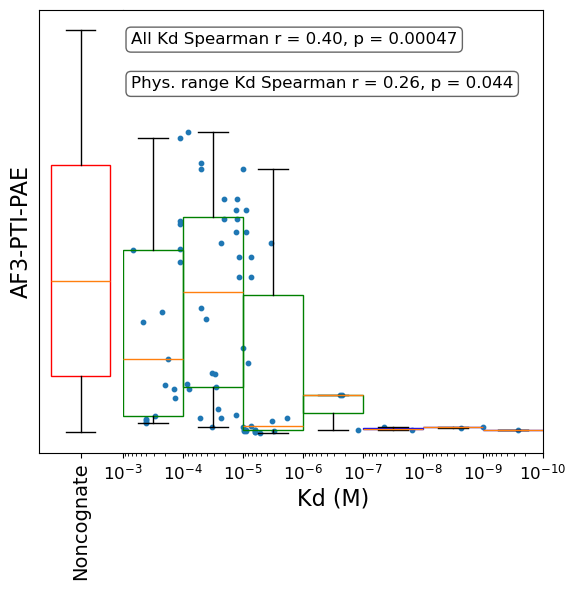

In [41]:
all_affin = (
    (
        both_iedb.join(
            affinity,
            on=[
                "references",
                "receptor_id",
                "peptide",
                "mhc_1_name",
                "mhc_2_name",
                "assay_type",
            ],
        )
    )
    .filter(pl.col("response").str.contains("KD"))
    .with_columns((pl.col("as_num_value")).alias("as_num_value"))
)

cls = all_affin.select("mhc_class").to_series().to_list()

val = all_affin.select("mean_p_tcr_interface_pae", "as_num_value").to_numpy()


noncog_affin = all_noncog.with_columns(pl.lit(None).alias("as_num_value")).join(
    all_affin.select(FORMAT_ANTIGEN_COLS).unique(), on=FORMAT_ANTIGEN_COLS, how="inner"
)

plot_af3_pti_pae_box_scatter(
    noncog_affin.select("mean_p_tcr_interface_pae").to_series().to_numpy(),
    all_affin.select(pl.col("as_num_value")).to_series().to_numpy() / 1e9,
    all_affin.select("mean_p_tcr_interface_pae").to_series().to_numpy(),
)

In [19]:
noncog_affin

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references,peptide_mean_pLDDT_II,as_num_value
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[list[str]],list[list[str]],f64,null
"""0003ad0033de5942d50b06cf69a73a…",false,"""NLVPMVATV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""AQKVTQAQTEISVVEKEDVTLDCVYETRDT…","""beta""","""human""","""NAGVMQNPRHLVRRRGQEARLRCSPMKGHS…","""TRDTTYY""","""RNSFDEQN""","""QKSTSS""","""CAADNAGNMLTF""","""KGHSH""","""LQKENI""","""PKEGP""","""CASSPGGTEAFF""",null,"[0.54, 0.58, … 0.37]","[[0.03, 0.93, … 0.21], [0.93, 0.88, … 0.25], … [0.21, 0.25, … 0.87]]","[[0.76, 1.24, … 22.43], [1.01, 0.76, … 20.360001], … [17.57, 14.35, … 0.76]]","[0.03, 0.88, … 0.87]",0.07,0.0,0.63,0.67,0.67,24.307886,…,0.011364,25.491308,20.532442,25.174206,22.356209,0.007709,0.007709,0.000657,0.000657,0,3,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",86.92723,70.182031,67.606,89.202094,79.755542,79.291282,76.791961,81.873056,79.495062,77.247859,90.900342,6.575426,4.990888,2.02225,3.826442,0.058945,0.058945,21.43,19.610001,17.15,13.44,null,null,null,null
"""0005b6889ad03b43facdab7fecddc7…",false,"""NLVPMVATV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""AQTVTQSQPEMSVQEAETVTLSCTYDTSES…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""TSESDYY""","""QEAYKQQN""","""QKAAKS""","""CAYGDDKIIF""","""LNHDA""","""SQIVND""","""EKKES""","""CASSIALSTFQPQHF""",null,"[0.53, 0.58, … 0.36]","[[0.02, 0.93, … 0.22], [0.93, 0.88, … 0.27], … [0.22, 0.27, … 0.85]]","[[0.76, 1.26, … 19.690001], [1.04, 0.76, … 18.299999], … [15.68, 12.79, … 0.76]]","[0.02, 0.88, … 0.85]",0.07,0.0,0.62,0.67,0.66,22.556389,…,0.012231,24.532631,19.857424,24.609119,21.705711,0.007368,0.007368,0.000555,0.000555,0,7,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",85.585077,73.602,68.329714,88.812093,80.995569,82.669487,75.139782,87.314286,73.008421,77.256531,89.601849,7.189229,5.169624,2.129662,4.234979,0.059845,0.059845,19.690001,18.299999,15.68,12.66,null,null,null,null
"""00084812771b1df4431568457a5cfb…",false,"""GILGFVFTL""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""ELKVEQNPLFLSMQEGKNYTIYCNYSTTSD…","""beta""","""human""","""NAGVTQTPKFQVLKTGQSMTL

In [ ]:
all_noncog.with_columns(pl.lit(None).alias("as_num_value")).select(FORMAT_ANTIGEN_COLS)

peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq
str,str,str,str,str,str,str,str,str,str
"""GMDYHNGHL""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
"""IWDYVNKELA""","""I""","""heavy""","""human""","""C*04:01""","""GSHSMRYFSTSVSWPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
"""SLSKILDTV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
"""NLLLQYGSFCTQLNRAL""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*15:01""","""GDTRPRFLWQPKRECHFFNGTERVRFLDRY…"
"""CLAVHECFV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
…,…,…,…,…,…,…,…,…,…
"""FLRGRAYVL""","""I""","""heavy""","""human""","""B*08:01""","""GSHSMRYFDTAMSRPGRGEPRFISVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
"""HLLLVAAGL""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…"
"""PKYVKQNTLKLAR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*01:01""","""GDTRPRFLWQLKFECHFFNGTERVRLLERC…"


In [7]:
all_affin.select(pl.col("as_num_value").min())

as_num_value
f64
0.26


In [8]:
all_affin.select(pl.col("as_num_value").max())

as_num_value
f64
670000.0


In [9]:
all_affin.select(pl.col("as_num_value").median())

as_num_value
f64
12850.0


In [21]:
med = (
    all_affin.with_columns(
        (
            (pl.col("mean_p_tcr_interface_pae").rank(method="average") - 1)
            / (pl.len() - 1)
        ).alias(f"mean_p_tcr_interface_pae_pct_rank")
    )
    .filter(pl.col("as_num_value") < 10**3)
    .select("mean_p_tcr_interface_pae")
    .median()
    .item()
)

pct = (
    all_affin.select(
        pl.when(pl.col("mean_p_tcr_interface_pae").is_not_null().sum() <= 1)
        .then(None)  # undefined if 0 or 1 non-null points (adjust if you want 0/1 here)
        .otherwise(
            (
                (pl.col("mean_p_tcr_interface_pae") < med).sum()
                + 0.5 * (pl.col("mean_p_tcr_interface_pae") == med).sum()
            )
            / (pl.col("mean_p_tcr_interface_pae").is_not_null().sum() - 1)
        )
        .alias("percentile_rank")
    )
).item()

pct

# .select(
#     "mean_p_tcr_interface_pae", "as_num_value", "mean_p_tcr_interface_pae_pct_rank"
# ).sort(
#     by="as_num_value"
# ).filter(
#     pl.col("as_num_value") < 10**3
# )

0.2

In [25]:
all_affin.with_columns(
    (
        (pl.col("mean_p_tcr_interface_pae").rank(method="average") - 1) / (pl.len() - 1)
    ).alias(f"mean_p_tcr_interface_pae_pct_rank")
).select(
    "mean_p_tcr_interface_pae", "as_num_value", "mean_p_tcr_interface_pae_pct_rank"
).sort(
    by="as_num_value"
).filter(
    pl.col("as_num_value") < 10**3
)

mean_p_tcr_interface_pae,as_num_value,mean_p_tcr_interface_pae_pct_rank
f64,f64,f64
2.224931,0.26,0.128571
2.437933,1.0,0.228571
2.386966,2.3,0.185714
2.224931,15.2,0.128571
2.419033,45.0,0.207143
2.224931,122.0,0.128571
4.730535,220.0,0.442857
4.759959,240.0,0.457143


## Eng vs non-eng


In [56]:
precursor = pl.DataFrame({"receptor_id": ["28112", "28788"]})

all_affin.join(precursor, on="receptor_id")

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references,assay_type,as_type_id,as_char_value,as_num_value,as_inequality,as_comments,mhc_class_right,category,response,units,obi_id
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,i64,str,f64,str,str,str,str,str,str,str
"""5d82006edff3537ae5cfb28a0cc40d…",true,"""ELAGIGILTV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""EAGVTQFPSHSVIEKGQTVTLRCDPISGHD…","""DRGSQS""","""IYSNGD""","""NKASQY""","""CAVSSSDFLMF""","""SGHDN""","""FVKESK""","""TGGTY""","""CASSHAGLGVEQYF""",true,"[0.87, 0.91, … 0.83]","[[0.03, 0.96, … 0.84], [0.96, 0.89, … 0.87], … [0.84, 0.87, … 0.87]]","[[0.76, 1.02, … 1.29], [0.93, 0.76, … 1.21], … [1.51, 1.56, … 0.76]]","[0.03, 0.89, … 0.87]",0.07,0.0,0.89,0.9,0.93,2.224931,…,30,30,"[[0.0, 0.0, … 0.0], [0.0, 1.0, … 4.0], … [0.0, 0.0, … 0.0]]",96.007826,90.560909,95.378696,92.806735,93.22,92.774167,89.961373,87.616471,93.849215,92.439527,93.227788,3.844901,4.660933,1.604427,2.111915,0.060232,0.060232,1.14,1.12,1.13,1.2,"""28112""","""1032856""","""surface plasmon resonance (SPR…",301,"""Positive-Low""",15.2,null,"""Soluble TCR affinity to the ep…","""I""","""T Cell""","""dissociation constant KD""","""nM""","""http://purl.obolibrary.org/obo…"


In [ ]:
iedb_I.explode("receptor_id").explode("receptor_id").filter(
    pl.col("receptor_id") == "28112"
)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,mean_tcr_p_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,list[list[str]]
"""5d82006edff3537ae5cfb28a0cc40d…",true,"""ELAGIGILTV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""EAGVTQFPSHSVIEKGQTVTLRCDPISGHD…","""DRGSQS""","""IYSNGD""","""NKASQY""","""CAVSSSDFLMF""","""SGHDN""","""FVKESK""","""TGGTY""","""CASSHAGLGVEQYF""",true,"[0.87, 0.91, … 0.83]","[[0.03, 0.96, … 0.84], [0.96, 0.89, … 0.87], … [0.84, 0.87, … 0.87]]","[[0.76, 1.02, … 1.29], [0.93, 0.76, … 1.21], … [1.51, 1.56, … 0.76]]","[0.03, 0.89, … 0.87]",0.07,0.0,0.89,0.9,0.93,2.224931,…,0.102172,0.01683,0.01683,3.708596,4.400686,6.792509,7.245248,0.013291,0.013291,0.000742,0.000742,30,30,"[[0.0, 0.0, … 0.0], [0.0, 1.0, … 4.0], … [0.0, 0.0, … 0.0]]",96.007826,90.560909,95.378696,92.806735,93.22,92.774167,89.961373,87.616471,93.849215,92.439527,93.227788,3.844901,4.660933,1.604427,2.111915,0.060232,0.060232,1.14,1.12,1.13,1.2,"""28112""","[[""1032856""]]"


In [ ]:
iedb_I.explode("references").explode("references").filter(
    pl.col("references") == "1034243"
)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,ranking_score,mean_p_tcr_interface_pae,…,mean_tcr_p_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,receptor_id,references
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[list[str]],str
"""2dcee7c6dfd10869881fd3c85296b4…",true,"""SLYNTVATL""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""DAGVTQSPTHLIKTRGQQVTLRCSPKSGHD…","""DRGSQS""","""IYSNGD""","""NKASQY""","""CAVRGAHDYALNF""","""SGHDT""","""YYEEEE""","""FPNYS""","""CSSDTVSYEQYF""",false,"[0.83, 0.89, … 0.81]","[[0.03, 0.94, … 0.78], [0.94, 0.89, … 0.86], … [0.78, 0.86, … 0.88]]","[[0.76, 1.08, … 1.94], [0.98, 0.76, … 1.58], … [1.94, 1.54, … 0.76]]","[0.03, 0.89, … 0.88]",0.07,0.0,0.89,0.9,0.93,3.2,…,0.059655,0.013053,0.013053,5.131277,4.450271,7.118066,7.192812,0.007798,0.007798,0.000709,0.000709,17,15,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 5.0], … [0.0, 0.0, … 0.0]]",92.022463,84.609319,93.741521,92.421429,92.5656,94.423143,92.432667,95.412273,94.07404,92.625514,93.858974,5.189554,4.785654,1.81645,2.828759,0.059567,0.059567,1.79,1.42,1.94,1.46,"[[""28786""]]","""1034243"""
"""351a68f3fdbf643b0c49a9ac1dcf8c…",true,"""AAGIGILTV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""EAGVTQFPSHSVIEKGQTVTLRCDPISGHD…","""DRGSQS""","""IYSNGD""","""NKASQY""","""CAVNDNARLMF""","""SGHDN""","""FVKESK""","""TGGTY""","""CASSHAGLGVEQYF""",true,"[0.77, 0.85, … 0.73]","[[0.02, 0.92, … 0.67], [0.92, 0.88, … 0.75], … [0.67, 0.75, … 0.87]]","[[0.76, 1.42, … 3.23], [1.08, 0.76, … 2.59], … [2.89, 2.53, … 0.76]]","[0.02, 0.88, … 0.87]",0.07,0.0,0.86,0.87,0.9,4.759959,…,0.093539,0.015198,0.015198,7.867812,5.54286,8.004327,8.790886,0.01139,0.01139,0.000778,0.000778,1,21,"[[0.0, 0.0, … 0.0], [1.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]",85.051579,84.287955,90.691304,91.18653,84.928471,87.264722,85.743333,87.787059,85.550098,86.784877,90.323144,7.262375,5.053024,2.150413,4.280911,0.065185,0.065185,2.54,1.85,2.33,1.94,"[[""28789""]]","""1034243"""
"""8de5e87ccdb413cfcf07a01eef9959…",true,"""ELAGIGILTV""","""I""","""heavy""","""human""","""A*02:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""light""","""human""","""B2M""","""MSRSVALAVLALLSLSGLEAIQRTPKIQVY…","""alpha""","""human""","""QKEVEQNSGPLSVPEGAIASLNCTYSDRGS…","""beta""","""human""","""EA

In [ ]:
iedb_I.explode("receptor_id").explode("receptor_id").join(
    precursor, on="receptor_id"
).select("peptide", "mean_p_tcr_interface_pae", "mhc_1_name")

peptide,mean_p_tcr_interface_pae,mhc_1_name
str,f64,str
"""AAGIGILTV""",4.759959,"""A*02:01"""
"""ELAGIGILTV""",2.224931,"""A*02:01"""
"""ELAGIGILTV""",2.224931,"""A*02:01"""
"""ELAGIGILTV""",2.224931,"""A*02:01"""
"""ELAGIGILTV""",2.386966,"""A*02:01"""
"""ELAGIGILTV""",2.419033,"""A*02:01"""
"""ELAGIGILTV""",2.437933,"""A*02:01"""
"""ALGIGILTV""",4.730535,"""A*02:01"""


In [ ]:
precursor = pl.DataFrame(
    {"receptor_id": ["28113", "28118", "28117", "28112", "28114", "28789"]}
)

all_affin.join(precursor, on="receptor_id").select(
    "peptide", "mean_p_tcr_interface_pae", "mhc_1_name"
)

peptide,mean_p_tcr_interface_pae,mhc_1_name
str,f64,str
"""ELAGIGILTV""",2.224931,"""A*02:01"""
"""ALGIGILTV""",4.730535,"""A*02:01"""
"""ELAGIGILTV""",2.386966,"""A*02:01"""
"""ELAGIGILTV""",2.224931,"""A*02:01"""
"""AAGIGILTV""",4.759959,"""A*02:01"""
"""ELAGIGILTV""",2.437933,"""A*02:01"""
"""ELAGIGILTV""",2.419033,"""A*02:01"""
"""ELAGIGILTV""",2.224931,"""A*02:01"""
